In [45]:
acf_pacf_quiz <- function(n = 120, lag.max = 30, seed = NULL) {
  if (!is.null(seed)) set.seed(seed)

  draw_coefficients <- function(order, type) {
    if (order == 13L) {
      z <- numeric(order)
      z[order] <- sample(c(-0.85, -0.75, 0.75, 0.85), 1)
      return(z)
    }

    repeat {
      z <- round(runif(order, -0.85, 0.85), 2)
      polynomial <- if (type == "ar") c(1, -z) else c(1, z)
      if (abs(z[order]) >= 0.3 && max(abs(z)) >= 0.6 &&
          all(Mod(polyroot(polynomial)) > 1.05)) return(z)
    }
  }

  ar_order <- sample(c(1:4, 13), 1)
  ma_order <- sample(c(1:4, 13), 1)
  arma_ar_order <- sample(1:3, 1)
  arma_ma_order <- sample(1:3, 1)

  repeat {
    arma_ar <- draw_coefficients(arma_ar_order, "ar")
    arma_ma <- draw_coefficients(arma_ma_order, "ma")
    if (arma_ar_order != arma_ma_order || max(abs(arma_ar + arma_ma)) >= 0.4) break
  }

  models <- list(
    list(
      process = sprintf("AR(%d)", ar_order),
      order = c(ar_order, 0, 0),
      ar = draw_coefficients(ar_order, "ar"),
      ma = numeric()
    ),
    list(
      process = sprintf("MA(%d)", ma_order),
      order = c(0, 0, ma_order),
      ar = numeric(),
      ma = draw_coefficients(ma_order, "ma")
    ),
    list(
      process = sprintf("ARMA(%d,%d)", arma_ar_order, arma_ma_order),
      order = c(arma_ar_order, 0, arma_ma_order),
      ar = arma_ar,
      ma = arma_ma
    )
  )

  models <- models[sample.int(3)]

  simulation_model <- function(x) {
    model <- list(order = x$order)
    if (length(x$ar)) model$ar <- x$ar
    if (length(x$ma)) model$ma <- x$ma
    model
  }

  series <- lapply(models, function(x) {
    arima.sim(model = simulation_model(x), n = n)
  })
  names(series) <- as.character(1:3)
  names(models) <- as.character(1:3)

  shuffle <- function(avoid = NULL) {
    repeat {
      z <- sample.int(3)
      if (all(z != 1:3) && (is.null(avoid) || !identical(z, avoid))) return(z)
    }
  }

  acf_order <- shuffle()
  pacf_order <- shuffle(acf_order)
  acf_labels <- as.character(as.roman(1:3))
  pacf_labels <- LETTERS[1:3]
  lag.max <- min(lag.max, n - 1L)

  old_par <- par(no.readonly = TRUE)
  on.exit(par(old_par), add = TRUE)

  layout(matrix(1:9, 3, 3, byrow = TRUE), widths = c(1.5, 1, 1))

  for (i in 1:3) {
    plot(series[[i]], main = as.character(i), ylab = "X")
    acf(series[[acf_order[i]]], main = acf_labels[i], lag.max = lag.max)
    pacf(series[[pacf_order[i]]], main = pacf_labels[i], lag.max = lag.max)
  }

  format_coefficients <- function(x) {
    if (!length(x)) return(NA_character_)
    paste(formatC(x, format = "f", digits = 2), collapse = ", ")
  }

  answer <- data.frame(
    Series = 1:3,
    Process = vapply(models, `[[`, character(1), "process"),
    AR = vapply(models, function(x) format_coefficients(x$ar), character(1)),
    MA = vapply(models, function(x) format_coefficients(x$ma), character(1)),
    ACF = acf_labels[match(1:3, acf_order)],
    PACF = pacf_labels[match(1:3, pacf_order)],
    check.names = FALSE
  )

  invisible(list(series = series, models = models, answer = answer))
}


In [46]:
options(repr.plot.width = 12, repr.plot.height = 7, repr.plot.res = 200)

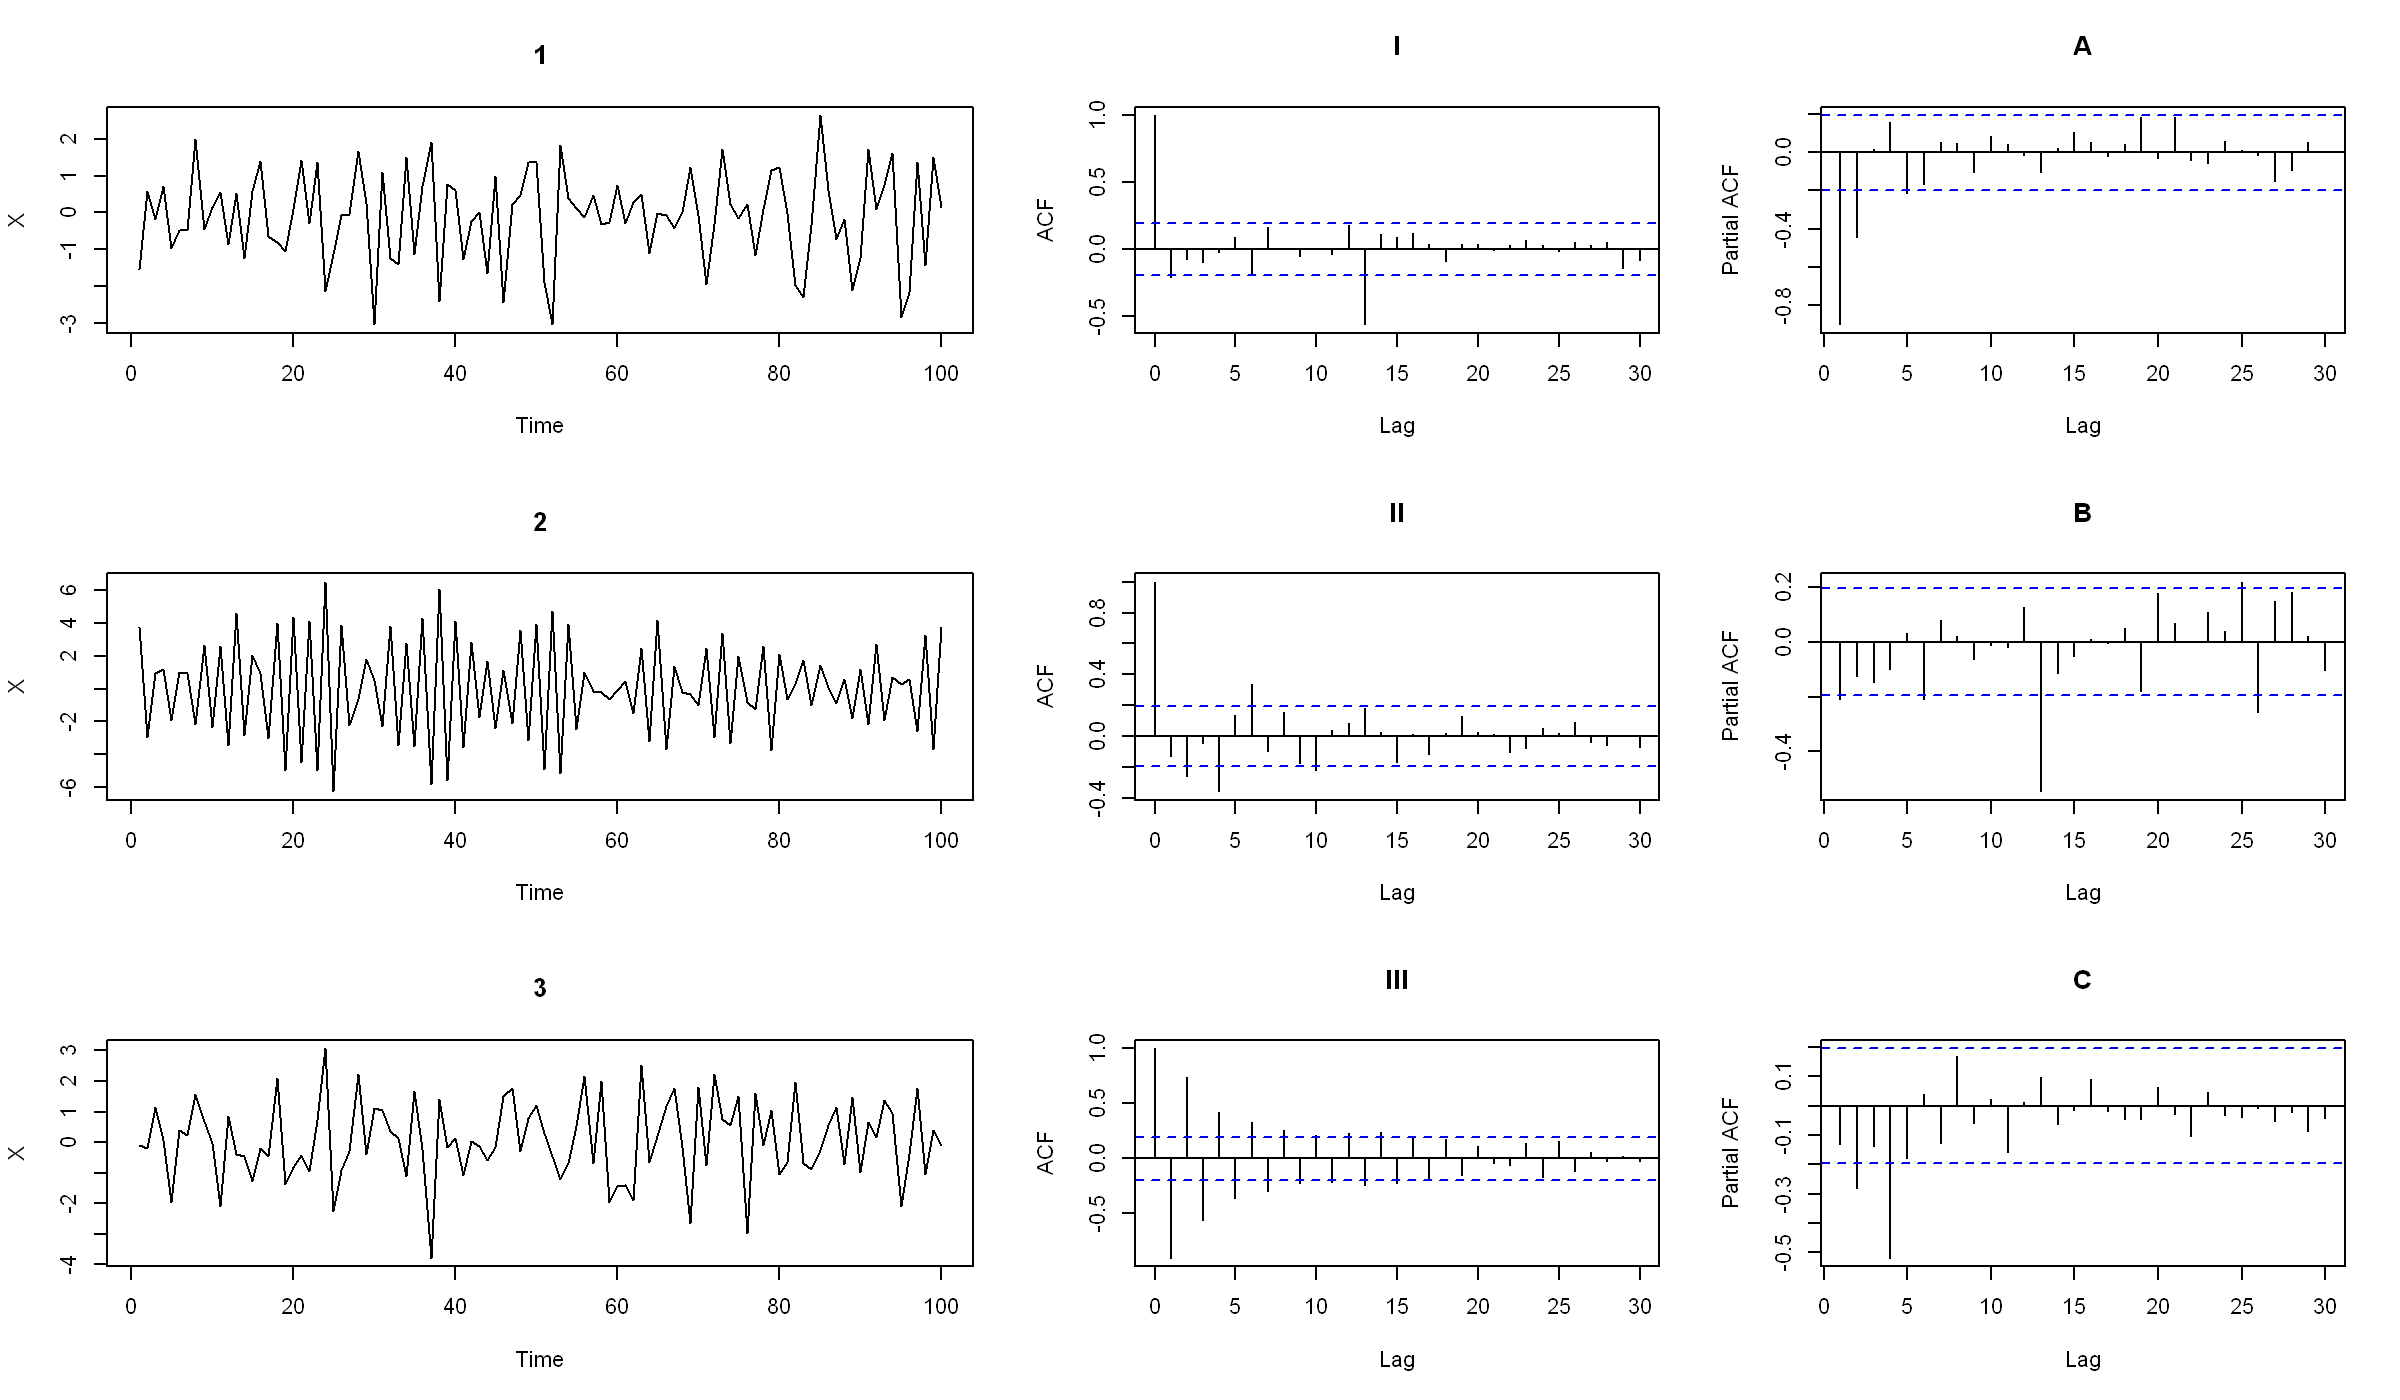

In [60]:
quiz <- acf_pacf_quiz(lag.max=30,n = 100)


1-I-B
2-III-A
3-II-C

In [61]:
quiz$answer

,Series,Process,AR,MA,ACF,PACF
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
1,1,AR(4),"-0.01, -0.41, -0.04, -0.61",NA,II,C
2,2,"ARMA(1,3)",-0.80,"-0.62, 0.76, -0.38",III,A
3,3,MA(13),NA,"0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, -0.85",I,B


In [59]:
abs(polyroot(c(1,-0.7,0.2)))
sqrt(5)

[1] 2.236068 2.236068

[1] 2.236068